# BCV Latents — Arena (nonlinear-linear, one fold)

Load one trained mSCA fold from the BCV nonlinear-linear results and visualise its latents.

In [1]:
import os, importlib
import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

import msca, msca.models, msca.architectures, msca.utils, msca.evaluations
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca.evaluations)
importlib.reload(msca)
from msca import mSCA

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## Config

Change `FOLD` to visualise a different neuron split (0–4).

In [ ]:
FOLD       = 0   
RESULTS_DIR = Path("./results/bi-cross-validation/nonlinear-linear")

# Must match what the arena NL models were actually trained with
MSCA_KWARGS = dict(
    n_components=20, loss_func="Poisson", n_epochs=5000, post_hoc_epoch=-1,
    linear=False, lam_region=0.0, decoder_type="linear",
    decoder_hidden_size=128, decoder_activation="GeLU",
    cd_rate=0.5, cd_mode="both", filter_len=41,
    init="unique", decoder_init_mode="pca",
    sparsity_warmup_epochs=1000, balance_interval=1000,
)

## Helper

In [3]:
BEHAVIOR_COLORS = [
    "#e60000", "#ff9900", "#663300", "#33cc00", "#00cccc",
    "#0000ff", "#a366ff", "#ff00ff", "#888800", "#009999",
]
_REGION_SHADE = (0.6, 1.55)


def _shade(color, factor):
    r, g, b = mcolors.to_rgb(color)
    if factor <= 1.0:
        return (r * factor, g * factor, b * factor)
    t = min(factor - 1.0, 1.0)
    return (r + (1 - r) * t, g + (1 - g) * t, b + (1 - b) * t)


def plot_latents(
    latents: dict,
    filter_len: int,
    title: str,
    out_path: Path,
    n_cols: int = 10,
    seed: int = 0,
    row_labels: list | None = None,
) -> None:
    rng = np.random.default_rng(seed)
    regions = list(latents.keys())
    K = latents[regions[0]][0].shape[1]
    n_trials = len(latents[regions[0]])

    trial_idxs = rng.choice(n_trials, size=n_cols, replace=False)

    cat = [np.concatenate([np.asarray(t) for t in latents[r]], axis=0) for r in regions]
    lo = np.minimum.reduce([c.min(axis=0) for c in cat])
    hi = np.maximum.reduce([c.max(axis=0) for c in cat])

    fig, axs = plt.subplots(K, n_cols, figsize=(14, 8), squeeze=True)

    for col, trial in enumerate(trial_idxs):
        color = BEHAVIOR_COLORS[col % len(BEHAVIOR_COLORS)]
        for row in range(K):
            ax = axs[row, col]
            for ri, reg in enumerate(regions):
                shade = _shade(color, _REGION_SHADE[ri % len(_REGION_SHADE)])
                ax.plot(np.asarray(latents[reg][trial])[:, row], color=shade, lw=1.2)
            ax.set_ylim(lo[row] - 0.2, hi[row] + 0.2)
            if col > 0:
                ax.set_yticks([])
            elif row_labels is not None and row < len(row_labels):
                ax.set_ylabel(row_labels[row], fontsize=6, rotation=0,
                              ha="right", va="center", labelpad=18)
            if row < K - 1:
                ax.set_xticks([])
            ax.tick_params(labelsize=5)
            if row == 0:
                ax.set_title(f"trial {trial}", fontsize=7, color=color)

    handles = [
        plt.Line2D([0], [0],
                   color=_shade("0.4", _REGION_SHADE[ri % len(_REGION_SHADE)]),
                   lw=2.0, label=reg)
        for ri, reg in enumerate(regions)
    ]
    fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=8)
    fig.suptitle(title, fontsize=10)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.show()

## 1. Load data and neuron splits

In [4]:
BEHAVIORS = [
    "climbdown", "climbup", "eating", "grooming", "jumpdown",
    "jumping", "rearing", "still", "walkflat", "walkgrid",
]

def _load_h5(filename):
    def _recurse(group):
        out = {}
        for key, item in group.items():
            out[key] = _recurse(item) if isinstance(item, h5py.Group) else item[()]
        return out
    with h5py.File(filename, "r") as f:
        return _recurse(f)

training_dataset = _load_h5("./data/arena_training_bin_size=10.h5")

X = {"cortex": [], "striatum": []}
behavior_labels = []

for beh_idx, behavior in enumerate(BEHAVIORS):
    v = training_dataset[behavior]
    n_trials = v["cortex"].shape[0]
    for region in X:
        X[region] += [v[region][i].astype("float32") for i in range(n_trials)]
    behavior_labels += [beh_idx] * n_trials

behavior_labels = np.array(behavior_labels)

train_idxs = torch.load(RESULTS_DIR / "n_train_splits.pt", weights_only=False)
test_idxs  = torch.load(RESULTS_DIR / "n_test_splits.pt",  weights_only=False)

print(f"Total trials: {len(X['cortex'])}")
print(f"Fold {FOLD} — training neurons: cortex={len(train_idxs['cortex'][FOLD])}, striatum={len(train_idxs['striatum'][FOLD])}")
print(f"Fold {FOLD} — held-out neurons: cortex={len(test_idxs['cortex'][FOLD])},  striatum={len(test_idxs['striatum'][FOLD])}")

Total trials: 1046
Fold 0 — training neurons: cortex=64, striatum=118
Fold 0 — held-out neurons: cortex=17,  striatum=30


## 2. Load BCV model for selected fold

In [5]:
X_train = {k: [trial[:, train_idxs[k][FOLD]] for trial in v] for k, v in X.items()}

model = mSCA(**MSCA_KWARGS)
model.load(str(RESULTS_DIR / f"msca_split_{FOLD}.pt"), X_train)

print(f"Loaded fold {FOLD}: n_components={model.n_components}, filter_len={model.filter_len}")

Using region-weights = {'cortex': 1.0060121289628752, 'striatum': 0.9940593035040507}
Using lam_sparse = adaptive
Using lam_orthog = 2716.4912006578948
Using lam_region = 0.0
Loaded fold 0: n_components=20, filter_len=41


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


## 3. Compute latents

In [ ]:
Z = model.transform(X_train)



## 4. Plot latents

/var/folders/lm/hpfh84_s6p71hgkdg87dg0cm0000gn/T/ipykernel_62363/1073355229.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


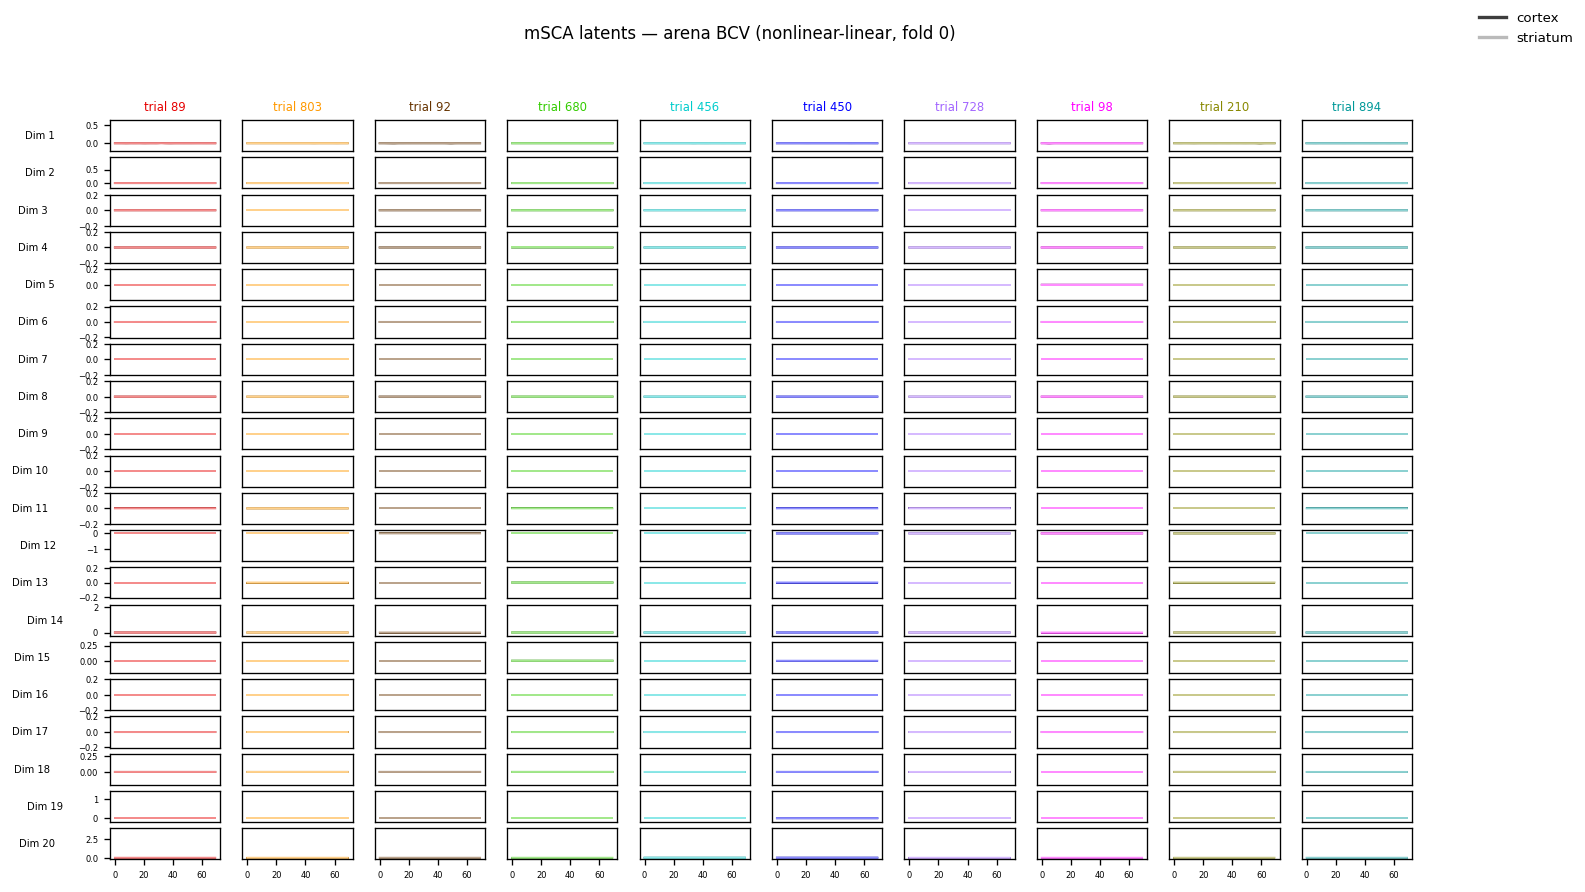

In [7]:
plot_latents(
    latents    = Z,
    filter_len = model.filter_len,
    title      = f"mSCA latents — arena BCV (nonlinear-linear, fold {FOLD})",
    out_path   = RESULTS_DIR / f"latents_fold{FOLD}.pdf",
    n_cols     = 10,
    seed       = 42,
    row_labels = [f"Dim {k+1}" for k in range(model.n_components)],
)

In [8]:
losses = np.load(RESULTS_DIR / f"losses_split_{FOLD}.npz")
LOSS_KEYS   = ["total_loss", "reconstruction", "latent_sparsity", "orthogonality"]
LOSS_LABELS = ["total", "recon", "sparse", "orthog"]
COLORS = ["#333333", "#1f77b4", "#ff7f0e", "#2ca02c"]

fig, axes = plt.subplots(1, len(LOSS_KEYS), figsize=(14, 3))

for ax, key, label, color in zip(axes, LOSS_KEYS, LOSS_LABELS, COLORS):
    if key in losses:
        ax.plot(losses[key], color=color, lw=1)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("epoch", fontsize=8)
    ax.grid(ls=":", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=7)

plt.suptitle("Training losses — arena (nonlinear decoder)", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for key, label, color in zip(LOSS_KEYS, LOSS_LABELS, COLORS):
    if key in losses:
        ax.plot(losses[key], color=color, lw=1, label=label)
ax.set_xlabel("epoch", fontsize=9)
ax.set_ylabel("loss", fontsize=9)
ax.legend(frameon=False, fontsize=8)
ax.grid(ls=":", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=7)
ax.set_title("Training losses — arena (nonlinear decoder)", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "losses.pdf", bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results/bi-cross-validation/nonlinear-linear/losses_split_0.npz'